In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
df=pd.read_csv("gurgaon_properties_missing_value_imputed.csv")

In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,3.25,14444.0,3,3,2,2.0,Old Property,2250.0,0,0,0,0,0,0,27
1,flat,bestech park view spa next,sector 67,2.70,11489.0,4,4,3+,9.0,Moderately Old,2127.0,0,1,0,1,0,1,149
2,house,international city by sobha phase 1,sector 109,6.75,10838.0,4,4,3+,2.0,New Property,6228.0,0,1,0,1,0,0,130
3,flat,hcbs sports ville,sohna road,0.38,5067.0,2,2,2,9.0,Relatively New,750.0,0,0,0,0,0,0,0
4,flat,m3m skywalk,sector 74,1.78,12500.0,2,2,3+,12.0,Relatively New,1582.0,0,0,0,0,0,0,63


In [ ]:
df.shape

(3557, 18)

In [ ]:
latlong = pd.read_csv('latlong.csv')

In [ ]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [ ]:
latlong['latitute'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [ ]:
latlong.head()

,sector,coordinates,latitute,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [ ]:
new_df = df.merge(latlong, on ='sector')

In [ ]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitute', 'longitude'],
      dtype='object')

In [ ]:
group_df = new_df.groupby('sector').mean(numeric_only=True)[['price','price_per_sqft','built_up_area','latitute','longitude']]

In [ ]:
group_df

,price,price_per_sqft,built_up_area,latitute,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
sector 103,1.488140,7416.488372,1867.162791,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.934000,5928.290000,1571.341800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326
sector 95,0.480545,5602.509091,995.981818,28.4172,76.9081


In [ ]:
fig = px.scatter_map(group_df, lat="latitute", lon="longitude", color="price_per_sqft", size="built_up_area",
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10, map_style="open-street-map", text=group_df.index)
fig.show()

In [ ]:
new_df.to_csv('data_viz1.csv',index=False)

In [ ]:
import plotly
plotly.__version__

'5.24.1'

In [ ]:
df1 =pd.read_csv('gurgaon_properties.csv')

In [ ]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 Bedroom House for sale in Sector 4 Gurgaon,house,independent,3.25,14444.0,2250.0,Plot area 250(209.03 sq.m.),3,3,2,not available,"Sector 4 Gurgaon, Gurgaon, Haryana",2.0,South-East,10+ Year Old,"['Chintapurni Mandir', 'State bank ATM', 'Prat...",250 square yards east facing single story made...,"['30 Light', 'No AC', 'No Bed', 'No Chimney', ...","['Feng Shui / Vaastu Compliant', 'Park', 'Visi...","['Environment5 out of 5', 'Lifestyle5 out of 5..."
1,4 BHK Flat in Sector 67 Gurgaon,flat,bestech park view spa next,2.70,11489.0,2350.0,Super Built up area 2350(218.32 sq.m.),4,4,3+,"pooja room,servant room","Middle Floor, Sector 67 Gurgaon, Gurgaon, Haryana",9.0,South-West,5 to 10 Year Old,"['Omaxe City Centre Mall', 'Golf Course Extens...",Located in the popular residential address of ...,"['4 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Ge...","['Centrally Air Conditioned', 'Security / Fire...","['Green Area5 out of 5', 'Construction4 out of..."
2,4 Bedroom House for sale in Sector 109 Gurgaon,house,international city by sobha phase 1,6.75,10838.0,6228.0,Plot area 692(578.6 sq.m.),4,4,3+,"servant room,pooja room","Sector 109 Gurgaon, Gurgaon, Haryana",2.0,North-East,0 to 1 Year Old,"['Dwarka sector 21 metro station', 'Pacific D2...",International city is an urban enclave of vill...,NaN,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Environment5 out of 5', 'Safety4.5 out of 5'..."
3,2 BHK Flat in Sohna,flat,hcbs sports ville,0.38,5067.0,750.0,Built Up area: 750 (69.68 sq.m.)Carpet area: 6...,2,2,2,not available,"Sohna, Sohna, Gurgaon, Haryana",9.0,East,undefined,"['The roadside cafe', 'GD Goenka Mess', 'ROyal...",Best in class property available at sohna loca...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,"['Green Area4 out of 5', 'Amenities4 out of 5'..."
4,2 BHK Flat in Sector 74 Gurgaon,flat,m3m skywalk,1.78,12500.0,1424.0,Carpet area: 1424 (132.29 sq.m.),2,2,3+,not available,"Sector 74, Delhi Gurgaon Expressway, Sector 74...",12.0,NaN,undefined,"['Omaxe Gurgaon Mall', 'Omaxe Celebration Mall...",Best in class property available at sector 74 ...,"['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,NaN


In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 4,3.25,14444.0,3,3,2,2.0,Old Property,2250.0,0,0,0,0,0,0,27
1,flat,bestech park view spa next,sector 67,2.70,11489.0,4,4,3+,9.0,Moderately Old,2127.0,0,1,0,1,0,1,149
2,house,international city by sobha phase 1,sector 109,6.75,10838.0,4,4,3+,2.0,New Property,6228.0,0,1,0,1,0,0,130
3,flat,hcbs sports ville,sohna road,0.38,5067.0,2,2,2,9.0,Relatively New,750.0,0,0,0,0,0,0,0
4,flat,m3m skywalk,sector 74,1.78,12500.0,2,2,3+,12.0,Relatively New,1582.0,0,0,0,0,0,0,63


In [ ]:
wordcloud_df=df1.merge(df,left_index=True, right_index=True)

In [ ]:
wordcloud_df[['features','sector']].head(5)

,features,sector
0,"['Feng Shui / Vaastu Compliant', 'Park', 'Visi...",sector 4
1,"['Centrally Air Conditioned', 'Security / Fire...",sector 67
2,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 109
3,NaN,sohna road
4,NaN,sector 74


In [ ]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [ ]:
main

['Feng Shui / Vaastu Compliant',
 'Park',
 'Visitor Parking',
 'Low Density Society',
 'Centrally Air Conditioned',
 'Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Water softening plant',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Water purifier',
 'Maintenance Staff',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Ligh

In [ ]:
from wordcloud import WordCloud

In [ ]:
feature_text = ' '.join(main)

In [ ]:
feature_text

'Feng Shui / Vaastu Compliant Park Visitor Parking Low Density Society Centrally Air Conditioned Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Piped-gas Internet/wi-fi connectivity Visitor Parking Swimming Pool Park Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Water purifier Maintenance Staff Water Storage Separate entry for servant room No open drainage around Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Fitness Centre / GYM Waste Disposal Rain Water Harvesting Club house / Community Center Feng Shui / Vaastu Compliant Priv

In [ ]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [ ]:
import wordcloud
wordcloud.__version__

'1.9.6'

In [ ]:
import matplotlib
matplotlib.__version__

'3.10.0'

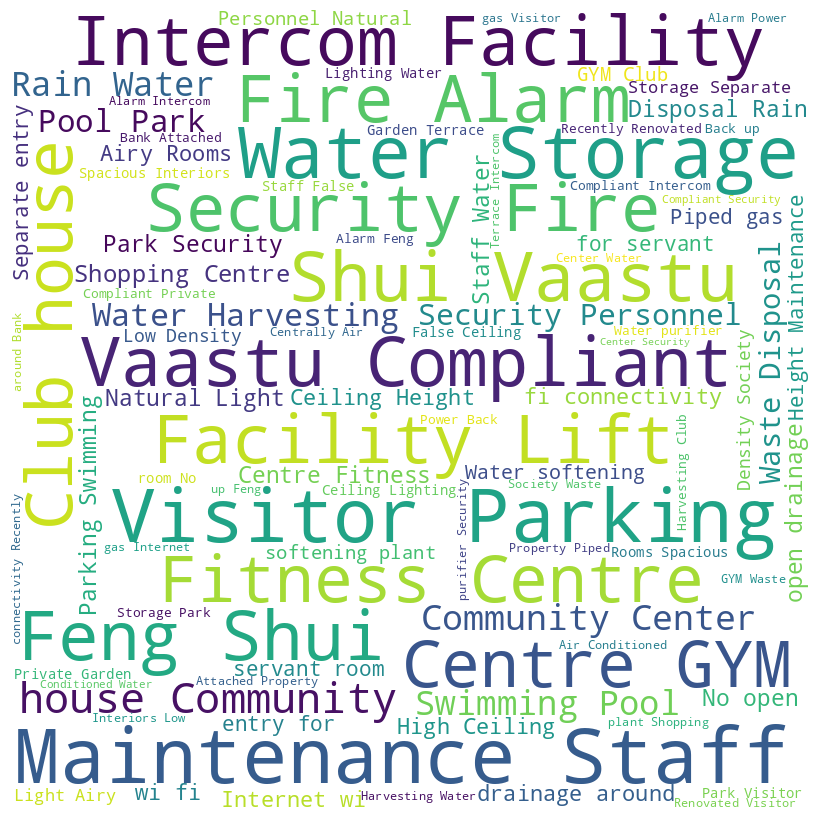

In [ ]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800,
                      background_color ='white',
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show() # st.pyplot()

In [ ]:
wordcloud_df=wordcloud_df.groupby('sector')['features'].apply(list)

In [ ]:
wordcloud_df.head()

,features
sector,
dwarka expressway,"[['Water purifier', 'Centrally Air Conditioned..."
gwal pahari,"[['Water Storage', 'Rain Water Harvesting'], [..."
manesar,"[['Security / Fire Alarm', 'Power Back-up', 'F..."
sector 1,"[nan, ['Feng Shui / Vaastu Compliant', 'Privat..."
sector 102,"[nan, ['Intercom Facility', 'Lift(s)', 'Swimmi..."


In [ ]:
wordcloud_df = wordcloud_df.reset_index()

In [ ]:
wordcloud_df.iloc[0,1]

["['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community Center']",
 "['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Water Storage', 'Park', 'Visitor Parking']",
 nan,
 nan,
 "['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Natural Light', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Center', 'Rain Water Harvesting']",
 "['Private Gar

In [ ]:
for item in wordcloud_df.iloc[0,1] :
  print(item)
  print(type(item))

['Water purifier', 'Centrally Air Conditioned', 'Security / Fire Alarm', 'Feng Shui / Vaastu Compliant', 'Private Garden / Terrace', 'High Ceiling Height', 'Maintenance Staff', 'False Ceiling Lighting', 'Water Storage', 'Separate entry for servant room', 'No open drainage around', 'Bank Attached Property', 'Piped-gas', 'Internet/wi-fi connectivity', 'Recently Renovated', 'Visitor Parking', 'Swimming Pool', 'Park', 'Security Personnel', 'Natural Light', 'Airy Rooms', 'Spacious Interiors', 'Low Density Society', 'Waste Disposal', 'Rain Water Harvesting', 'Fitness Centre / GYM', 'Club house / Community Center']
<class 'str'>
['Security / Fire Alarm', 'Intercom Facility', 'Lift(s)', 'Water Storage', 'Park', 'Visitor Parking']
<class 'str'>
nan
<class 'float'>
nan
<class 'float'>
['Power Back-up', 'Feng Shui / Vaastu Compliant', 'Intercom Facility', 'Lift(s)', 'Maintenance Staff', 'Park', 'Natural Light', 'Airy Rooms', 'Shopping Centre', 'Fitness Centre / GYM', 'Club house / Community Cente

In [ ]:
import ast
def convert(x):
    l = []
    for item in x:
        if type(item) == str:
            item = ast.literal_eval(item)
            for i in range(len(item)):
                l.append(item[i])
        elif type(item) == float:
            continue
    return l

In [ ]:
wordcloud_df['features'] = wordcloud_df['features'].apply(convert)

In [ ]:
wordcloud_df.head()

,sector,features
0,dwarka expressway,"[Water purifier, Centrally Air Conditioned, Se..."
1,gwal pahari,"[Water Storage, Rain Water Harvesting, Power B..."
2,manesar,"[Security / Fire Alarm, Power Back-up, Feng Sh..."
3,sector 1,"[Feng Shui / Vaastu Compliant, Private Garden ..."
4,sector 102,"[Intercom Facility, Lift(s), Swimming Pool, Pa..."


In [ ]:
wordcloud_df.to_csv('wordcloud_df.csv',index=False)

In [ ]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area vs Price")
fig.show()

In [ ]:
fig2 = px.pie(df,names='bedRoom')
fig2.show()

In [ ]:
temp_df = df[df['bedRoom'] <= 4]
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')
fig.show()

/tmp/ipykernel_3013/3761596323.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


/tmp/ipykernel_3013/3761596323.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

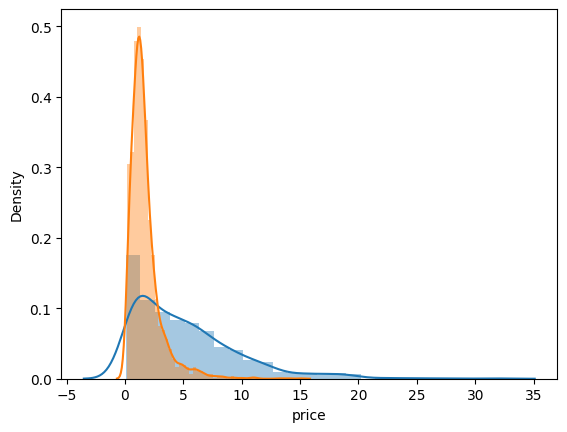

In [ ]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])

In [ ]:
import seaborn
seaborn.__version__

'0.13.2'